In [ ]:
import matplotlib.pyplot as plt
import torch

from unet import UNet
from data import S2Scene

In [ ]:
#scene = S2Scene('data/stuttgart/sen2_stuttgart_20260430.tif')
scene = S2Scene('data/lindau/sen2_lindau_20250619.tif')
#scene = S2Scene('data/rom/sen2_rom_20250603.tif')

In [3]:
scene.data.shape

(4, 359, 496)

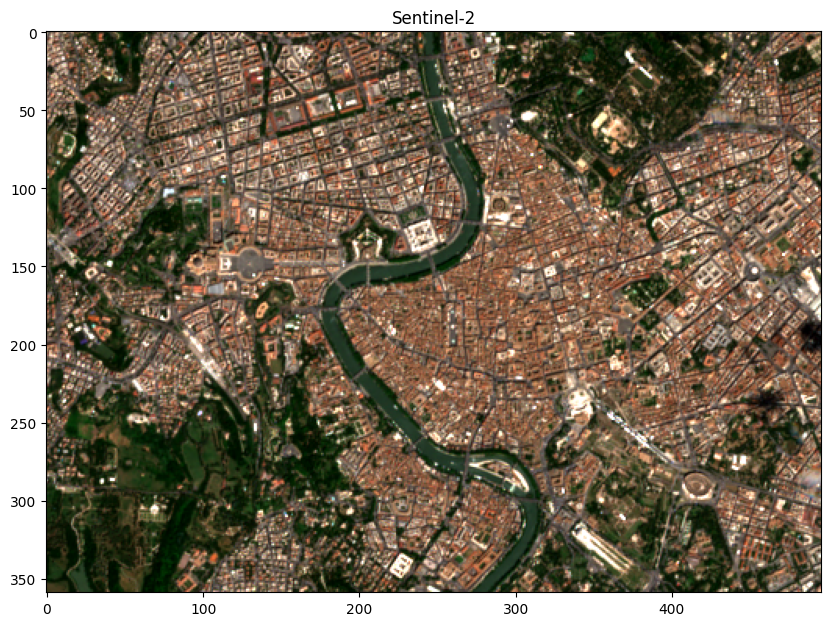

In [4]:
scene.display()

In [5]:
model = UNet(n_channels=4, n_classes=12)

model_path = "/home/mommermi/hft/events/2026_05_3DForumLindau/tutorial/workbench/unet_sen2_esaworldcover.pth"
model.load_state_dict(torch.load(model_path, weights_only=True, map_location=torch.device('cpu')))
model.eval()

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

In [9]:
x = torch.unsqueeze(torch.Tensor(scene.data), dim=0)

with torch.no_grad():
    output = model(x)[0]

    pred = torch.argmax(output, dim=0)
    pred.shape


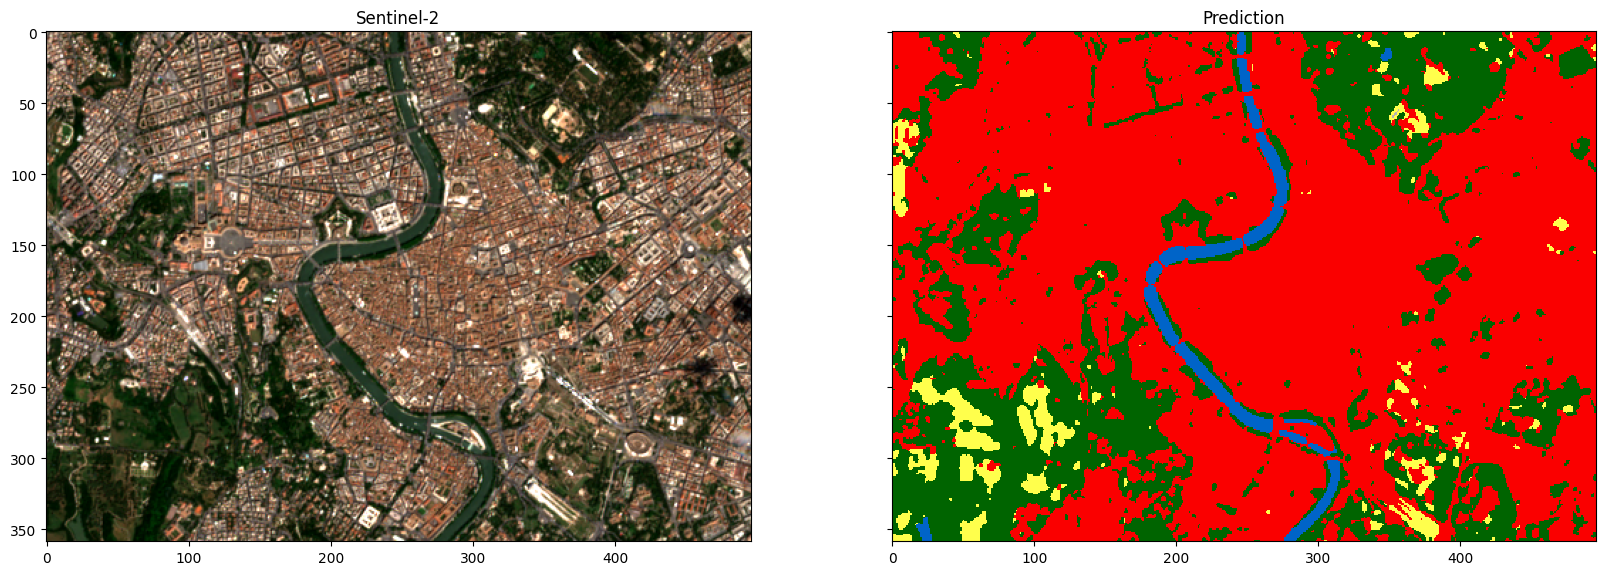

In [10]:
#scene.display(pred=pred, aoi=(200, 500, 350, 400))
scene.display(pred=pred)